In [1]:
from qiskit.transpiler.passes import RemoveBarriers

from combine_data import combine_data
from datetime import datetime

from labels import VQEParameters
from hamiltonian.base import HamiltonianParameters
from misc import data_folder
from solver.circuits import rebuild_ansatz, BaseADAPTVQEAnsatz
import h5py
from plotter import ResultLoader
from matplotlib import pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection
import matplotlib as mpl
import numpy as np
from qiskit import generate_preset_pass_manager, compiler
from numpyencoder import NumpyEncoder
import json
from misc import plots_folder
from pathlib import Path
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh

backend = FakeMarrakesh()
approximation_degree = 0.999
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
output_filename = plots_folder
# temp = "2025-09-35"
# output_filename += temp
output_filename += datetime.now().strftime('%Y-%m-%U')  #datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
Path(output_filename).mkdir(parents=True, exist_ok=True)
output_filename += "/"
output_filename

'results/plots/2026-07-30/'

In [3]:
combine_data()

-----Combining data-----
Skipping combined file 2026-02-08.hdf5
Skipping combined file 2025-10-43.hdf5
Skipping combined file 2025-08-34.hdf5
Skipping combined file 2025-09-35.hdf5
Skipping combined file 2026-07-30.hdf5
Skipping combined file 2025-11-46.hdf5
Skipping combined file 2025-10-42.hdf5
Skipping combined file 2026-07-29.hdf5
Skipping combined file 2026-01-02.hdf5
Skipping combined file 2025-11-45.hdf5
Skipping combined file 2025-08-33.hdf5
Skipping combined file 2025-11-44.hdf5
Skipping combined file 2026-01-01.hdf5
-----Finished combining data-----


# 1. VQE and ED

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
    vqe_1_loader = ResultLoader(f["2025-09-02_17-46-07"])  # 4 layers, 5000 max iterations
    vqe_1_energy, vqe_1_mass = vqe_1_loader.get_energy_mass({})
    vqe_1_h_var, vqe_1_mass_h_var = vqe_1_loader.get_hamiltonian_variance_mass({})
    vqe_2_loader = ResultLoader(f["2025-09-03_11-10-56"])  # 4 layers, 20000 max iterations
    vqe_2_energy, vqe_2_mass = vqe_2_loader.get_energy_mass({})
    vqe_2_h_var, vqe_2_mass_h_var = vqe_2_loader.get_hamiltonian_variance_mass({})
    vqe_3_loader = ResultLoader(f["2025-09-03_11-11-36"])  # 2 layers, 20000 max iterations
    vqe_3_energy, vqe_3_mass = vqe_3_loader.get_energy_mass({})
    vqe_3_h_var, vqe_3_mass_h_var = vqe_3_loader.get_hamiltonian_variance_mass({})
    vqe_4_loader = ResultLoader(f["2025-09-03_11-12-33"])  # 8 layers, 20000 max iterations
    vqe_4_energy, vqe_4_mass = vqe_4_loader.get_energy_mass({})
    vqe_4_h_var, vqe_4_mass_h_var = vqe_4_loader.get_hamiltonian_variance_mass({})

## 1.1 ED

In [ ]:
fig, ax = plt.subplots(layout="constrained")
ax.set_axisbelow(True)
ax.grid(True)
# ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=color_cycle[2])[0].set_label("Higher excited states")
# ax.plot(ed_mass + 2, ed_energy[:, 1], label="First excited state", color=color_cycle[1])
# ax.plot(ed_mass + 2, ed_energy[:, 0], label="Ground state", color=color_cycle[0])
gs_color = "black"
es_color = "green"
opacity = 0.75
hes_color = (1 - opacity) * np.array(mpl.colors.to_rgba("white")) + opacity * np.array(mpl.colors.to_rgba("sienna"))
# lc = LineCollection([list(zip(ed_mass + 2, ed_energy[:, i])) for i in range(2,68)], color=hes_color, alpha=0.5)
# lc.set_label("Higher excited states")
# ax.add_collection(lc)
ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=hes_color)[0].set_label("Higher excited states")
ax.plot(ed_mass + 2, ed_energy[:, 1], label="First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="Ground state", color=gs_color)
ax.set(xlabel='$m+2r$', ylabel=r'$E$')
es_color = "dimgray"

ax.legend()
fig.savefig(f"{output_filename}ed.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}ed.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 1.2 VQE: Varying $I_{\text{max}}$

In [ ]:
fig, (ax, var_ax) = plt.subplots(2, sharex=True, figsize=(6.4, 4.8 * 1.5), layout="constrained",
                                 height_ratios=[2, 1])

var_ax.set_axisbelow(True)
var_ax.grid(True)
ax.set_axisbelow(True)
ax.grid(True)

var_ax.set(xlabel='$m+2r$', ylabel=r'$\sigma_H$')
var_ax.set_yscale("log")
ax.set(ylabel=r'$E$')

var_ax.scatter(vqe_1_mass_h_var + 2, np.sqrt(vqe_1_h_var), label=r"VQE: $I_{\text{max}}=5000$",
               marker='.', s=64, color=color_cycle[0])
var_ax.scatter(vqe_2_mass_h_var + 2, np.sqrt(vqe_2_h_var), label=r"VQE: $I_{\text{max}}=20000$",
               marker='.', s=16, color=color_cycle[1])

ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)
ax.errorbar(vqe_1_mass + 2, vqe_1_energy, np.sqrt(vqe_1_h_var), label=r"VQE: $I_{\text{max}}=5000$", zorder=2.5, ls="",
            marker=".", ms=8, color=color_cycle[0])
ax.errorbar(vqe_2_mass + 2, vqe_2_energy, np.sqrt(vqe_2_h_var), label=r"VQE: $I_{\text{max}}=20000$", zorder=2.5, ls="",
            marker=".", ms=4, color=color_cycle[1])

var_ax.legend()
ax.legend()

fig.savefig(f"{output_filename}vqe_varying_iterations.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}vqe_varying_iterations.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 1.3 VQE: Varying $N_{\text{layers}}$

In [ ]:
fig, (ax, var_ax) = plt.subplots(2, sharex=True, figsize=(6.4, 4.8 * 1.5), layout="constrained",
                                 height_ratios=[2, 1])

var_ax.set_axisbelow(True)
var_ax.grid(True)
ax.set_axisbelow(True)
ax.grid(True)

var_ax.set(xlabel='$m+2r$', ylabel=r'$\sigma_H$')
var_ax.set_yscale("log")
ax.set(ylabel=r'$E$')

var_ax.scatter(vqe_3_mass_h_var + 2, np.sqrt(vqe_3_h_var), label=r"VQE: $N_{\text{layers}}=2$", zorder=2.5,
               marker='.', s=64, color=color_cycle[0])
var_ax.scatter(vqe_2_mass_h_var + 2, np.sqrt(vqe_2_h_var), label=r"VQE: $N_{\text{layers}}=4$", zorder=2.6,
               marker='.', s=16, color=color_cycle[1])
var_ax.scatter(vqe_4_mass_h_var + 2, np.sqrt(vqe_4_h_var), label=r"VQE: $N_{\text{layers}}=8$", zorder=2.4,
               marker='*', s=64, color=color_cycle[2])

p1 = ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)[0]
p2 = ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)[0]

bar1 = ax.errorbar(vqe_4_mass + 2, vqe_4_energy, np.sqrt(vqe_4_h_var), label=r"VQE: $N_{\text{layers}}=8$", zorder=2.5,
                   ls="",
                   marker="*", ms=8, color=color_cycle[2], ecolor=color_cycle[3])
bar2 = ax.errorbar(vqe_3_mass + 2, vqe_3_energy, np.sqrt(vqe_3_h_var), label=r"VQE: $N_{\text{layers}}=2$", zorder=2.5,
                   ls="",
                   marker=".", ms=8, color=color_cycle[0])
bar3 = ax.errorbar(vqe_2_mass + 2, vqe_2_energy, np.sqrt(vqe_2_h_var), label=r"VQE: $N_{\text{layers}}=4$", zorder=2.5,
                   ls="",
                   marker=".", ms=4, color=color_cycle[1])

temp_fig, temp_ax = plt.subplots(1)
bar1 = temp_ax.errorbar(vqe_4_mass + 2, vqe_4_energy, np.sqrt(vqe_4_h_var), label=r"VQE: $N_{\text{layers}}=8$",
                        zorder=2.5, ls="",
                        marker="*", ms=6, color=color_cycle[2], ecolor=color_cycle[3])

plt.close(temp_fig)

var_ax.legend()
ax.legend([p1, p2, bar2, bar3, bar1],
          ["ED: First excited state", "ED: Ground state", r"VQE: $N_{\text{layers}}=2$", r"VQE: $N_{\text{layers}}=4$",
           r"VQE: $N_{\text{layers}}=8$"])

fig.savefig(f"{output_filename}vqe_varying_layer_count.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}vqe_varying_layer_count.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

### Circuit with 2 layers

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    vqe_4_loader = ResultLoader(f["2025-09-03_11-12-33"])  # 8 layers, 20000 max iterations
    circuit_4 = vqe_4_loader.get_circuit({}, trim=True)
    vqe_2_loader = ResultLoader(f["2025-09-03_11-10-56"])  # 4 layers, 20000 max iterations
    circuit_2 = vqe_2_loader.get_circuit({}, trim=True)
    vqe_3_loader = ResultLoader(f["2025-09-03_11-11-36"])  # 2 layers, 20000 max iterations
    circuit_3 = vqe_3_loader.get_circuit({}, trim=True)
circuit_3.reverse_bits().draw("latex_source", filename=f"{output_filename}vqe_circuit_2_layers.txt")
circuit_3.reverse_bits().draw("mpl", filename=f"{output_filename}vqe_circuit_2_layers.pdf")
# circuit = circuit.decompose().decompose().decompose().decompose()

circuit_4 = compiler.transpile(RemoveBarriers()(circuit_4), backend=backend, seed_transpiler=42, optimization_level=3,
                               approximation_degree=approximation_degree)
print(circuit_4.count_ops())
vqe_8_layers_2_qubit_depth = circuit_4.depth(lambda instr: len(instr.qubits) > 1)
vqe_8_layers_2_qubit_count = circuit_4.num_nonlocal_gates()

circuit_2 = compiler.transpile(RemoveBarriers()(circuit_2), backend=backend, seed_transpiler=42, optimization_level=3,
                               approximation_degree=approximation_degree)
print(circuit_2.count_ops())
vqe_4_layers_2_qubit_depth = circuit_2.depth(lambda instr: len(instr.qubits) > 1)
vqe_4_layers_2_qubit_count = circuit_2.num_nonlocal_gates()

circuit_3 = compiler.transpile(RemoveBarriers()(circuit_3), backend=backend, seed_transpiler=42, optimization_level=3,
                               approximation_degree=approximation_degree)
print(circuit_3.count_ops())
vqe_2_layers_2_qubit_depth = circuit_3.depth(lambda instr: len(instr.qubits) > 1)
vqe_2_layers_2_qubit_count = circuit_3.num_nonlocal_gates()
print(
    f"2 layers: \t 2-Qubit gate depth: {vqe_2_layers_2_qubit_depth}; 2-Qubit gate count: {vqe_2_layers_2_qubit_count}")
print(
    f"4 layers: \t 2-Qubit gate depth: {vqe_4_layers_2_qubit_depth}; 2-Qubit gate count: {vqe_4_layers_2_qubit_count}")
print(
    f"8 layers: \t 2-Qubit gate depth: {vqe_8_layers_2_qubit_depth}; 2-Qubit gate count: {vqe_8_layers_2_qubit_count}")
circuit_3.draw("mpl")

## 1.3 VQE: Varying seeds

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    vqe_s1_loader = ResultLoader(f["2025-09-03_11-10-56"])  # 4 layers, 20000 max iterations
    vqe_s1_energy, vqe_s1_mass = vqe_s1_loader.get_energy_mass({})
    vqe_s1_h_var, vqe_s1_mass_h_var = vqe_s1_loader.get_hamiltonian_variance_mass({})
    vqe_s2_loader = ResultLoader(f["2025-09-06_15-50-13"])  # 4 layers, 20000 max iterations
    vqe_s2_energy, vqe_s2_mass = vqe_s2_loader.get_energy_mass({})
    vqe_s2_h_var, vqe_s2_mass_h_var = vqe_s2_loader.get_hamiltonian_variance_mass({})
    vqe_s3_loader = ResultLoader(f["2025-09-06_15-50-13-23147802"])  # 4 layers, 20000 max iterations
    vqe_s3_energy, vqe_s3_mass = vqe_s3_loader.get_energy_mass({})
    vqe_s3_h_var, vqe_s3_mass_h_var = vqe_s3_loader.get_hamiltonian_variance_mass({})
    vqe_s4_loader = ResultLoader(f["2025-09-06_15-50-13-23147804"])  # 4 layers, 20000 max iterations
    vqe_s4_energy, vqe_s4_mass = vqe_s4_loader.get_energy_mass({})
    vqe_s4_h_var, vqe_s4_mass_h_var = vqe_s4_loader.get_hamiltonian_variance_mass({})
    vqe_s5_loader = ResultLoader(f["2025-09-06_15-50-13-23147805"])  # 4 layers, 20000 max iterations
    vqe_s5_energy, vqe_s5_mass = vqe_s5_loader.get_energy_mass({})
    vqe_s5_h_var, vqe_s5_mass_h_var = vqe_s5_loader.get_hamiltonian_variance_mass({})

fig, (ax, var_ax) = plt.subplots(2, sharex=True, figsize=(6.4, 4.8 * 1.5), layout="constrained",
                                 height_ratios=[2, 1])

var_ax.set_axisbelow(True)
var_ax.grid(True)
ax.set_axisbelow(True)
ax.grid(True)

var_ax.set(xlabel='$m+2r$', ylabel=r'$\sigma_H$')
var_ax.set_yscale("log")
ax.set(ylabel=r'$E$')

var_ax.scatter(vqe_s1_mass_h_var + 2, np.sqrt(vqe_s1_h_var), label=r"VQE 1",
               marker='s', s=32, color=color_cycle[0], facecolors="none")
var_ax.scatter(vqe_s2_mass_h_var + 2, np.sqrt(vqe_s2_h_var), label=r"VQE 2",
               marker='^', s=32, color=color_cycle[1], facecolors="none")
var_ax.scatter(vqe_s4_mass_h_var + 2, np.sqrt(vqe_s4_h_var), label=r"VQE 3",
               marker='.', s=32, color=color_cycle[2])
var_ax.scatter(vqe_s5_mass_h_var + 2, np.sqrt(vqe_s5_h_var), label=r"VQE 4",
               marker='.', s=8, color=color_cycle[3])

ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.scatter(vqe_s1_mass + 2, vqe_s1_energy, label=r"VQE 1", marker='s', s=64, color=color_cycle[0], zorder=2.5,
           facecolors="none")
ax.scatter(vqe_s2_mass + 2, vqe_s2_energy, label=r"VQE 2", marker='^', s=40, color=color_cycle[1], zorder=2.5,
           facecolors="none")
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)
ax.scatter(vqe_s4_mass + 2, vqe_s4_energy, label=r"VQE 3", marker='.', s=32, color=color_cycle[2], zorder=2.5)
ax.scatter(vqe_s5_mass + 2, vqe_s5_energy, label=r"VQE 4", marker='.', s=8, color=color_cycle[3], zorder=2.5)

var_ax.legend(ncol=2)
ax.legend(ncol=2)

fig.savefig(f"{output_filename}vqe_varying_seeds.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}vqe_varying_seeds.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 1.5 VQE: Energy minimization

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    vqe_2_loader = ResultLoader(f["2025-09-03_11-10-56"])  # 4 layers, 20000 max iterations

    params = {HamiltonianParameters.Mass: 40}
    param_values = vqe_2_loader.get_parameter_values_from_indices(params)
    print([f"{x}={y:.3f}" for x, y in param_values.items()])

    vqe_2_energy_evolution = vqe_2_loader.get_energy_evolution(params)
    print(len(vqe_2_energy_evolution))
fig, (ax1, ax2) = plt.subplots(2, sharex=True)
ax1.set_axisbelow(True)
ax1.grid(True)
ax1.tick_params(axis="x", which="both", direction="in", bottom=True)
ax2.set_axisbelow(True)
ax2.grid(True)
fig.subplots_adjust(hspace=0)
ax1.plot(vqe_2_energy_evolution, color=color_cycle[0])
ax1.set(ylabel=r'$f_c$')
ax2.plot(np.abs(vqe_2_energy_evolution - vqe_2_energy_evolution[-1]), color=color_cycle[0])
ax2.set_xlim((0, len(vqe_2_energy_evolution) - 1))
ax2.set_yscale("log")
ax2.set(xlabel='Iteration $I$', ylabel=r'$|f_c-f_{c,\text{final}}|$')
fig.savefig(f"{output_filename}vqe_energy_evolution.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}vqe_energy_evolution.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

# 2. ADAPT-VQE

## 2.1 ADAPT - VQE: Naive greedy pool from VQE

In [ ]:
fig, ax = plt.subplots(layout="constrained")
ax.set_axisbelow(True)
ax.grid(True)
ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=hes_color)[0].set_label("ED: Higher excited states")
ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)
# See eigenstate test: These were the first runs where ADAPT-VQE didn't start,
# the fixed states has energy 0 and variance 4 for all values of m
ax.errorbar(np.linspace(-6, 2, 50) + 2, np.zeros(50), np.ones(50) * 2, label=r"ADAPT-VQE", zorder=2.5, ls="",
            marker=".", ms=8, color=color_cycle[0])
ax.set(xlabel='$m+2r$', ylabel=r'$E$')
ax.legend()
fig.savefig(f"{output_filename}adapt_vqe_1_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_1_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 2.2 ADAPT - VQE: Not so naive greedy pool

### 2.2.1 Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2025-10-43"}.hdf5", "r") as f:
    avqe_1_loader = ResultLoader(f["2025-10-27_17-21-26-23769494"])
    print(avqe_1_loader.get_hamiltonian_type())
    avqe_1_energy, avqe_1_mass = avqe_1_loader.get_energy_mass({})
    avqe_1_f_c, _ = avqe_1_loader.get_hamiltonian_mass({})
    avqe_1_h_var, avqe_1_mass_v = avqe_1_loader.get_hamiltonian_variance_mass({})

fig, (ax, var_ax, pen_ax) = plt.subplots(3, sharex=True, figsize=(6.4, 4.8 * 1.5), layout="constrained",
                                         height_ratios=[2, 0.75, 0.25])

pen_ax.set_axisbelow(True)
pen_ax.grid(True)
var_ax.set_axisbelow(True)
var_ax.grid(True)
ax.set_axisbelow(True)
ax.grid(True)

pen_ax.set(xlabel='$m+2r$', ylabel=r'$f_c-E$')
var_ax.set(ylabel=r'$\sigma_H$')
var_ax.set_yscale("log")
ax.set(ylabel=r'$E$')

pen_ax.scatter(avqe_1_mass + 2, avqe_1_f_c - avqe_1_energy, label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

var_ax.scatter(avqe_1_mass_v + 2, np.sqrt(avqe_1_h_var), label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=hes_color)[0].set_label("ED: Higher excited states")
ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)
ax.errorbar(avqe_1_mass + 2, avqe_1_energy, np.sqrt(avqe_1_h_var), label="ADAPT-VQE", zorder=2.5, ls="",
            marker=".", ms=8, color=color_cycle[0])

pen_ax_y_lim = pen_ax.get_ylim()
pen_ax_scaler = 0.1
pen_ax.set_ylim([pen_ax_y_lim[0] - pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0]),
                 pen_ax_y_lim[1] + pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0])])
pen_ax.legend()
var_ax.legend(loc="center right")
ax.legend()
fig.savefig(f"{output_filename}adapt_vqe_2_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_2_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

### 2.2.2 Energy-Evolution

In [ ]:
for mass_i in [0, 20]:
    with h5py.File(f"{data_folder}{"2025-10-43"}.hdf5", "r") as f:
        avqe_1_loader = ResultLoader(f["2025-10-27_17-21-26-23769494"])

        params = {HamiltonianParameters.Mass: mass_i}
        param_values = avqe_1_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        avqe_1_energy_evolution = avqe_1_loader.get_energy_evolution(params)
        avqe_1_start_it = np.array(avqe_1_loader.get_start_iterations(params))
        avqe_1_op_labels = avqe_1_loader.get_operator_labels(params)
    fig, (ax1, ax2) = plt.subplots(2, sharex=True)
    ax1.set_axisbelow(True)
    ax1.grid(True)
    ax1.tick_params(axis="x", which="both", direction="in", bottom=True)
    ax2.set_axisbelow(True)
    ax2.grid(True)
    fig.subplots_adjust(hspace=0)

    ax1.plot(avqe_1_energy_evolution, color=color_cycle[1])
    ax1.set(ylabel=r'$f_c$')

    ax2.plot(np.abs(avqe_1_energy_evolution - avqe_1_energy_evolution[-1]), color=color_cycle[1])
    ax2.set_xlim((0, len(avqe_1_energy_evolution) - 1))
    ax2.set_yscale("log")
    ax2.set(xlabel='Iteration $I$', ylabel=r'$|f_c-f_{c,\text{final}}|$')

    ax1_y_lim = ax1.get_ylim()
    ax2_y_lim = ax2.get_ylim()

    cmap = plt.get_cmap("winter")
    norm = plt.Normalize(vmin=0, vmax=len(avqe_1_start_it) - 1)

    for i, (label, it) in enumerate(zip(avqe_1_op_labels, avqe_1_start_it)):
        ax1.vlines(it, ax1_y_lim[0], ax1_y_lim[1], linestyle="--", color=cmap(norm(i)), zorder=1.5, label=label)
        ax2.vlines(it, ax2_y_lim[0], ax2_y_lim[1], linestyle="--", color=cmap(norm(i)), zorder=1.5)

    ax1.set_ylim(ax1_y_lim)
    ax2.set_ylim(ax2_y_lim)
    fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

    fig.savefig(f"{output_filename}adapt_vqe_2_energy_evolution_{mass_i}.png", bbox_inches='tight', pad_inches=0,
                transparent=True)
    fig.savefig(f"{output_filename}adapt_vqe_2_energy_evolution_{mass_i}.pdf", bbox_inches='tight', pad_inches=0,
                transparent=True)

### 2.2.3 Example circuits

In [ ]:
for mass_i in [0, 20]:
    with h5py.File(f"{data_folder}{"2025-10-43"}.hdf5", "r") as f:
        avqe_1_loader = ResultLoader(f["2025-10-27_17-21-26-23769494"])

        params = {HamiltonianParameters.Mass: mass_i}
        param_values = avqe_1_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        circuit = avqe_1_loader.get_circuit(params, trim=True)
    circuit.reverse_bits().draw("latex_source", filename=f"{output_filename}adapt_vqe_2_circuit_{mass_i}.txt")
    circuit.reverse_bits().draw("mpl", filename=f"{output_filename}adapt_vqe_2_circuit_{mass_i}.pdf")
    pm = generate_preset_pass_manager()
    circuit = circuit.decompose().decompose().decompose()
    print(
        f"2-Qubit gate depth: {circuit.depth(lambda instr: len(instr.qubits) > 1)}; 2-Qubit gate count: {circuit.num_nonlocal_gates()}")

## 2.2.4 CNOT depth and count

In [ ]:
with h5py.File(f"{data_folder}{"2025-10-43"}.hdf5", "r") as f:
    avqe_1_loader = ResultLoader(f["2025-10-27_17-21-26-23769494"])
    avqe_1_2_qubit_depth = []
    avqe_1_2_qubit_count = []
    for mass_i in range(50):
        params = {HamiltonianParameters.Mass: mass_i}
        circuit = avqe_1_loader.get_circuit(params, trim=True)
        # circuit = circuit.decompose().decompose().decompose()
        circuit = compiler.transpile(RemoveBarriers()(circuit), backend=backend, seed_transpiler=42,
                                     optimization_level=3, approximation_degree=approximation_degree)
        avqe_1_2_qubit_depth.append(circuit.depth(lambda instr: len(instr.qubits) > 1))
        avqe_1_2_qubit_count.append(circuit.num_nonlocal_gates())
circuit.draw("mpl")

## 2.3 ADAPT - VQE: Best greedy pool

### 2.3.1 Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2025-11-46"}.hdf5", "r") as f:
    avqe_2_loader = ResultLoader(f["2025-11-18_13-11-50-23954408"])
    print(avqe_2_loader.get_hamiltonian_type())
    avqe_2_energy, avqe_2_mass = avqe_2_loader.get_energy_mass({})
    avqe_2_f_c, _ = avqe_2_loader.get_hamiltonian_mass({})
    avqe_2_h_var, avqe_2_mass_v = avqe_2_loader.get_hamiltonian_variance_mass({})

fig, (ax, var_ax, pen_ax) = plt.subplots(3, sharex=True, figsize=(6.4, 4.8 * 1.5), layout="constrained",
                                         height_ratios=[2, 0.75, 0.25])

pen_ax.set_axisbelow(True)
pen_ax.grid(True)
var_ax.set_axisbelow(True)
var_ax.grid(True)
ax.set_axisbelow(True)
ax.grid(True)

pen_ax.set(xlabel='$m+2r$', ylabel=r'$f_c-E$')
var_ax.set(ylabel=r'$\sigma_H$')
var_ax.set_yscale("log")
ax.set(ylabel=r'$E$')

pen_ax.scatter(avqe_2_mass + 2, avqe_2_f_c - avqe_2_energy, label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

var_ax.scatter(avqe_2_mass_v + 2, np.sqrt(avqe_2_h_var), label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=hes_color)[0].set_label("ED: Higher excited states")
ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)
ax.errorbar(avqe_2_mass + 2, avqe_2_energy, np.sqrt(avqe_2_h_var), label="ADAPT-VQE", zorder=2.5, ls="",
            marker=".", ms=8, color=color_cycle[0])

ax_x_lim = ax.get_xlim()
ax_y_lim = ax.get_ylim()
pen_ax_y_lim = pen_ax.get_ylim()
pen_ax_scaler = 0.1
pen_ax.set_ylim([pen_ax_y_lim[0] - pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0]),
                 pen_ax_y_lim[1] + pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0])])
pen_ax.legend()
var_ax.legend()
ax.legend()
fig.savefig(f"{output_filename}adapt_vqe_3_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_3_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

### 2.3.2 Example circuits

In [ ]:
for mass_i in [0, 20, 49]:
    with h5py.File(f"{data_folder}{"2025-11-46"}.hdf5", "r") as f:
        avqe_2_loader = ResultLoader(f["2025-11-18_13-11-50-23954408"])

        params = {HamiltonianParameters.Mass: mass_i}
        param_values = avqe_2_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        circuit = avqe_2_loader.get_circuit(params, trim=True)
    circuit.reverse_bits().draw("latex_source", filename=f"{output_filename}adapt_vqe_3_circuit_{mass_i}.txt")
    circuit.reverse_bits().draw("mpl", filename=f"{output_filename}adapt_vqe_3_circuit_{mass_i}.pdf")
    pm = generate_preset_pass_manager()
    circuit = circuit.decompose().decompose().decompose()
    print(
        f"2-Qubit gate depth: {circuit.depth(lambda instr: len(instr.qubits) > 1)}; 2-Qubit gate count: {circuit.num_nonlocal_gates()}")

## 2.3.3 C-Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
    ed_c, _ = ed_loader.get_charge_conjugation_mass({})
    ed_c_v, _ = ed_loader.get_charge_conjugation_variance_mass({})

with h5py.File(f"{data_folder}{"2025-11-46"}.hdf5", "r") as f:
    avqe_2_loader = ResultLoader(f["2025-11-18_13-11-50-23954408"])
    print(avqe_2_loader.get_hamiltonian_type())
    avqe_2_energy, avqe_2_mass = avqe_2_loader.get_energy_mass({})
    avqe_2_f_c, _ = avqe_2_loader.get_hamiltonian_mass({})
    avqe_2_h_var, avqe_2_mass_v = avqe_2_loader.get_hamiltonian_variance_mass({})
    avqe_2_c, avqe_2_mass_c = avqe_2_loader.get_charge_conjugation_mass({})

fig, ax = plt.subplots(layout="constrained")
ax.set_axisbelow(True)
ax.grid(True)
ax.set(xlabel='$m+2r$', ylabel=r'$E$')

cmap = plt.get_cmap('bwr')
norm = plt.Normalize(vmin=-1, vmax=1)

for i in range(68):
    points = np.array([ed_mass + 2, ed_energy[:, i]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(ed_c[:, i])
    lc.set_zorder(2)
    if i == 0:
        lc.set_label("ED: Energy eigenstates")
    line = ax.add_collection(lc)

ax.scatter(avqe_2_mass + 2, avqe_2_energy, c=avqe_2_c, norm=norm, cmap=cmap, label="ADAPT-VQE", marker='.',
           s=64, zorder=2.5, edgecolor="black", linewidths=0.5)

ax.set_xlim(ax_x_lim)
ax.set_ylim(ax_y_lim)

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\left\langle C \right\rangle$')

ax.legend(loc="lower center")
fig.show()

fig.savefig(f"{output_filename}adapt_vqe_3_c_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_3_c_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 2.3.4 CNOT depth and count

In [ ]:
with h5py.File(f"{data_folder}{"2025-11-46"}.hdf5", "r") as f:
    avqe_2_loader = ResultLoader(f["2025-11-18_13-11-50-23954408"])
    avqe_2_2_qubit_depth = []
    avqe_2_2_qubit_count = []
    for mass_i in range(50):
        params = {HamiltonianParameters.Mass: mass_i}
        circuit = avqe_2_loader.get_circuit(params, trim=True)
        # circuit = circuit.decompose().decompose().decompose()
        circuit = compiler.transpile(RemoveBarriers()(circuit), backend=backend, seed_transpiler=42,
                                     optimization_level=3, approximation_degree=approximation_degree)
        avqe_2_2_qubit_depth.append(circuit.depth(lambda instr: len(instr.qubits) > 1))
        avqe_2_2_qubit_count.append(circuit.num_nonlocal_gates())
circuit.draw("mpl")

## 2.4 ADAPT - VQE: C-Invariant 1

### 2.4.1 Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-01"}.hdf5", "r") as f:
    avqe_3_loader = ResultLoader(f["2026-01-07_14-31-34-24236398"])
    print(avqe_3_loader.get_hamiltonian_type())
    avqe_3_energy, avqe_3_mass = avqe_3_loader.get_energy_mass({})
    avqe_3_f_c, _ = avqe_3_loader.get_hamiltonian_mass({})
    avqe_3_h_var, avqe_3_mass_v = avqe_3_loader.get_hamiltonian_variance_mass({})

fig, (ax, var_ax, pen_ax) = plt.subplots(3, sharex=True, figsize=(6.4, 4.8 * 1.5), layout="constrained",
                                         height_ratios=[2, 0.75, 0.25])

pen_ax.set_axisbelow(True)
pen_ax.grid(True)
var_ax.set_axisbelow(True)
var_ax.grid(True)
ax.set_axisbelow(True)
ax.grid(True)

pen_ax.set(xlabel='$m+2r$', ylabel=r'$f_c-E$')
var_ax.set(ylabel=r'$\sigma_H$')
var_ax.set_yscale("log")
ax.set(ylabel=r'$E$')

pen_ax.scatter(avqe_3_mass + 2, avqe_3_f_c - avqe_3_energy, label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

var_ax.scatter(avqe_3_mass_v + 2, np.sqrt(avqe_3_h_var), label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=hes_color)[0].set_label("ED: Higher excited states")
ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)
ax.errorbar(avqe_3_mass + 2, avqe_3_energy, np.sqrt(avqe_3_h_var), label="ADAPT-VQE", zorder=2.5, ls="",
            marker=".", ms=8, color=color_cycle[0])

ax_x_lim = ax.get_xlim()
ax_y_lim = ax.get_ylim()
pen_ax_y_lim = pen_ax.get_ylim()
pen_ax_scaler = 0.1
pen_ax.set_ylim([pen_ax_y_lim[0] - pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0]),
                 pen_ax_y_lim[1] + pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0])])

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
var_ax.yaxis.set_major_formatter(formatter)
var_ax.yaxis.set_minor_formatter(formatter)

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
pen_ax.yaxis.set_major_formatter(formatter)
# pen_ax.yaxis.set_minor_formatter(formatter)

pen_ax.legend()
var_ax.legend()
ax.legend()
fig.savefig(f"{output_filename}adapt_vqe_4_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_4_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

### 2.4.2 Example circuits

In [ ]:
for mass_i in [0, 20, 49]:
    with h5py.File(f"{data_folder}{"2026-01-01"}.hdf5", "r") as f:
        avqe_3_loader = ResultLoader(f["2026-01-07_14-31-34-24236398"])

        params = {HamiltonianParameters.Mass: mass_i}
        param_values = avqe_3_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        circuit = avqe_3_loader.get_circuit(params, trim=True)
    circuit.reverse_bits().draw("latex_source", filename=f"{output_filename}adapt_vqe_4_circuit_{mass_i}.txt")
    circuit.reverse_bits().draw("mpl", filename=f"{output_filename}adapt_vqe_4_circuit_{mass_i}.pdf")
    pm = generate_preset_pass_manager()
    circuit = circuit.decompose().decompose().decompose()
    print(
        f"2-Qubit gate depth: {circuit.depth(lambda instr: len(instr.qubits) > 1)}; 2-Qubit gate count: {circuit.num_nonlocal_gates()}")

## 2.4.3 C-Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-01"}.hdf5", "r") as f:
    avqe_3_loader = ResultLoader(f["2026-01-07_14-31-34-24236398"])
    print(avqe_3_loader.get_hamiltonian_type())
    avqe_3_energy, avqe_3_mass = avqe_3_loader.get_energy_mass({})
    avqe_3_f_c, _ = avqe_3_loader.get_hamiltonian_mass({})
    avqe_3_h_var, avqe_3_mass_v = avqe_3_loader.get_hamiltonian_variance_mass({})
    avqe_3_c, avqe_3_mass_c = avqe_3_loader.get_charge_conjugation_mass({})

fig, ax = plt.subplots(layout="constrained")
ax.set_axisbelow(True)
ax.grid(True)
ax.set(xlabel='$m+2r$', ylabel=r'$E$')

cmap = plt.get_cmap('bwr')
norm = plt.Normalize(vmin=-1, vmax=1)

for i in range(68):
    points = np.array([ed_mass + 2, ed_energy[:, i]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(ed_c[:, i])
    lc.set_zorder(2)
    if i == 0:
        lc.set_label("ED: Energy eigenstates")
    line = ax.add_collection(lc)

ax.scatter(avqe_3_mass + 2, avqe_3_energy, c=avqe_3_c, norm=norm, cmap=cmap, label="ADAPT-VQE", marker='.',
           s=64, zorder=2.5, edgecolor="black", linewidths=0.5)

ax.set_xlim(ax_x_lim)
ax.set_ylim(ax_y_lim)

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\left\langle C \right\rangle$')

ax.legend(loc="lower center")
fig.show()

fig.savefig(f"{output_filename}adapt_vqe_4_c_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_4_c_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 2.4.4 CNOT depth and count

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-01"}.hdf5", "r") as f:
    avqe_3_loader = ResultLoader(f["2026-01-07_14-31-34-24236398"])
    avqe_3_2_qubit_depth = []
    avqe_3_2_qubit_count = []
    for mass_i in range(50):
        params = {HamiltonianParameters.Mass: mass_i}
        circuit = avqe_3_loader.get_circuit(params, trim=True)
        # circuit = circuit.decompose().decompose().decompose()
        circuit = compiler.transpile(RemoveBarriers()(circuit), backend=backend, seed_transpiler=42,
                                     optimization_level=3, approximation_degree=approximation_degree)
        avqe_3_2_qubit_depth.append(circuit.depth(lambda instr: len(instr.qubits) > 1))
        avqe_3_2_qubit_count.append(circuit.num_nonlocal_gates())
circuit.draw("mpl")

## 2.5 ADAPT - VQE: C-Invariant 2

### 2.5.1 Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
    avqe_4_loader = ResultLoader(f["2026-01-11_00-57-15-24245100"])
    print(avqe_4_loader.get_hamiltonian_type())
    avqe_4_energy, avqe_4_mass = avqe_4_loader.get_energy_mass({})
    avqe_4_f_c, _ = avqe_4_loader.get_hamiltonian_mass({})
    avqe_4_h_var, avqe_4_mass_v = avqe_4_loader.get_hamiltonian_variance_mass({})

fig, (ax, var_ax, pen_ax) = plt.subplots(3, sharex=True, figsize=(6.4, 4.8 * 1.5), layout="constrained",
                                         height_ratios=[2, 0.75, 0.25])

pen_ax.set_axisbelow(True)
pen_ax.grid(True)
var_ax.set_axisbelow(True)
var_ax.grid(True)
ax.set_axisbelow(True)
ax.grid(True)

pen_ax.set(xlabel='$m+2r$', ylabel=r'$f_c-E$')
var_ax.set(ylabel=r'$\sigma_H$')
var_ax.set_yscale("log")
ax.set(ylabel=r'$E$')

pen_ax.scatter(avqe_4_mass + 2, avqe_4_f_c - avqe_4_energy, label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

var_ax.scatter(avqe_4_mass_v + 2, np.sqrt(avqe_4_h_var), label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=hes_color)[0].set_label("ED: Higher excited states")
ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)
ax.errorbar(avqe_4_mass + 2, avqe_4_energy, np.sqrt(avqe_4_h_var), label="ADAPT-VQE", zorder=2.5, ls="",
            marker=".", ms=8, color=color_cycle[0])

ax_x_lim = ax.get_xlim()
ax_y_lim = ax.get_ylim()
pen_ax_y_lim = pen_ax.get_ylim()
pen_ax_scaler = 0.1
pen_ax.set_ylim([pen_ax_y_lim[0] - pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0]),
                 pen_ax_y_lim[1] + pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0])])

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
var_ax.yaxis.set_major_formatter(formatter)
var_ax.yaxis.set_minor_formatter(formatter)

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
pen_ax.yaxis.set_major_formatter(formatter)
# pen_ax.yaxis.set_minor_formatter(formatter)

pen_ax.legend()
var_ax.legend()
ax.legend()
fig.savefig(f"{output_filename}adapt_vqe_5_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_5_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

### 2.5.2 Example circuits

In [ ]:
for mass_i in [0, 20, 49]:
    with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
        avqe_4_loader = ResultLoader(f["2026-01-11_00-57-15-24245100"])

        params = {HamiltonianParameters.Mass: mass_i}
        param_values = avqe_4_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        circuit = avqe_4_loader.get_circuit(params, trim=True)
    circuit.reverse_bits().draw("latex_source", filename=f"{output_filename}adapt_vqe_5_circuit_{mass_i}.txt")
    circuit.reverse_bits().draw("mpl", filename=f"{output_filename}adapt_vqe_5_circuit_{mass_i}.pdf")
    pm = generate_preset_pass_manager()
    circuit = circuit.decompose().decompose().decompose()
    print(
        f"2-Qubit gate depth: {circuit.depth(lambda instr: len(instr.qubits) > 1)}; 2-Qubit gate count: {circuit.num_nonlocal_gates()}")

## 2.5.3 C-Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
    avqe_4_loader = ResultLoader(f["2026-01-11_00-57-15-24245100"])
    print(avqe_4_loader.get_hamiltonian_type())
    avqe_4_energy, avqe_4_mass = avqe_4_loader.get_energy_mass({})
    avqe_4_f_c, _ = avqe_4_loader.get_hamiltonian_mass({})
    avqe_4_h_var, avqe_4_mass_v = avqe_4_loader.get_hamiltonian_variance_mass({})
    avqe_4_c, avqe_4_mass_c = avqe_4_loader.get_charge_conjugation_mass({})

fig, ax = plt.subplots(layout="constrained")
ax.set_axisbelow(True)
ax.grid(True)
ax.set(xlabel='$m+2r$', ylabel=r'$E$')

cmap = plt.get_cmap('bwr')
norm = plt.Normalize(vmin=-1, vmax=1)

for i in range(68):
    points = np.array([ed_mass + 2, ed_energy[:, i]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(ed_c[:, i])
    lc.set_zorder(2)
    if i == 0:
        lc.set_label("ED: Energy eigenstates")
    line = ax.add_collection(lc)

ax.scatter(avqe_4_mass + 2, avqe_4_energy, c=avqe_4_c, norm=norm, cmap=cmap, label="ADAPT-VQE", marker='.',
           s=64, zorder=2.5, edgecolor="black", linewidths=0.5)

ax.set_xlim(ax_x_lim)
ax.set_ylim(ax_y_lim)

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\left\langle C \right\rangle$')

ax.legend(loc="lower center")
fig.show()

fig.savefig(f"{output_filename}adapt_vqe_5_c_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_5_c_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 2.5.4 CNOT depth and count

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
    avqe_4_loader = ResultLoader(f["2026-01-11_00-57-15-24245100"])
    avqe_4_2_qubit_depth = []
    avqe_4_2_qubit_count = []
    for mass_i in range(50):
        params = {HamiltonianParameters.Mass: mass_i}
        circuit = avqe_4_loader.get_circuit(params, trim=True)
        # circuit = circuit.decompose().decompose().decompose()
        circuit = compiler.transpile(RemoveBarriers()(circuit), backend=backend, seed_transpiler=42,
                                     optimization_level=3, approximation_degree=approximation_degree)
        avqe_4_2_qubit_depth.append(circuit.depth(lambda instr: len(instr.qubits) > 1))
        avqe_4_2_qubit_count.append(circuit.num_nonlocal_gates())
circuit.draw("mpl")

## 2.6 ADAPT - VQE: C-Invariant 3

### 2.6.1 Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
    avqe_5_loader = ResultLoader(f["2026-01-11_01-16-50-24245112"])
    print(avqe_5_loader.get_hamiltonian_type())
    avqe_5_energy, avqe_5_mass = avqe_5_loader.get_energy_mass({})
    avqe_5_f_c, _ = avqe_5_loader.get_hamiltonian_mass({})
    avqe_5_h_var, avqe_5_mass_v = avqe_5_loader.get_hamiltonian_variance_mass({})

fig, (ax, var_ax, pen_ax) = plt.subplots(3, sharex=True, figsize=(6.4, 4.8 * 1.5), layout="constrained",
                                         height_ratios=[2, 0.75, 0.25])

pen_ax.set_axisbelow(True)
pen_ax.grid(True)
var_ax.set_axisbelow(True)
var_ax.grid(True)
ax.set_axisbelow(True)
ax.grid(True)

pen_ax.set(xlabel='$m+2r$', ylabel=r'$f_c-E$')
var_ax.set(ylabel=r'$\sigma_H$')
var_ax.set_yscale("log")
ax.set(ylabel=r'$E$')

pen_ax.scatter(avqe_5_mass + 2, avqe_5_f_c - avqe_5_energy, label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

var_ax.scatter(avqe_5_mass_v + 2, np.sqrt(avqe_5_h_var), label="ADAPT-VQE",
               marker='.', s=64, color=color_cycle[0])

ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=hes_color)[0].set_label("ED: Higher excited states")
ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)
ax.errorbar(avqe_5_mass + 2, avqe_5_energy, np.sqrt(avqe_5_h_var), label="ADAPT-VQE", zorder=2.5, ls="",
            marker=".", ms=8, color=color_cycle[0])

ax_x_lim = ax.get_xlim()
ax_y_lim = ax.get_ylim()
pen_ax_y_lim = pen_ax.get_ylim()
pen_ax_scaler = 0.1
pen_ax.set_ylim([pen_ax_y_lim[0] - pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0]),
                 pen_ax_y_lim[1] + pen_ax_scaler * (pen_ax_y_lim[1] - pen_ax_y_lim[0])])

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
var_ax.yaxis.set_major_formatter(formatter)
var_ax.yaxis.set_minor_formatter(formatter)

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
pen_ax.yaxis.set_major_formatter(formatter)
# pen_ax.yaxis.set_minor_formatter(formatter)

pen_ax.legend()
var_ax.legend()
ax.legend()
fig.savefig(f"{output_filename}adapt_vqe_6_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_6_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

### 2.6.2 Example circuits

In [ ]:
for mass_i in [0, 20, 49]:
    with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
        avqe_5_loader = ResultLoader(f["2026-01-11_01-16-50-24245112"])

        params = {HamiltonianParameters.Mass: mass_i}
        param_values = avqe_5_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        circuit = avqe_5_loader.get_circuit(params, trim=True)
    circuit.reverse_bits().draw("latex_source", filename=f"{output_filename}adapt_vqe_6_circuit_{mass_i}.txt")
    circuit.reverse_bits().draw("mpl", filename=f"{output_filename}adapt_vqe_6_circuit_{mass_i}.pdf")
    pm = generate_preset_pass_manager()
    circuit = circuit.decompose().decompose().decompose()
    print(
        f"2-Qubit gate depth: {circuit.depth(lambda instr: len(instr.qubits) > 1)}; 2-Qubit gate count: {circuit.num_nonlocal_gates()}")

## 2.6.3 C-Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
    avqe_5_loader = ResultLoader(f["2026-01-11_01-16-50-24245112"])
    print(avqe_5_loader.get_hamiltonian_type())
    avqe_5_energy, avqe_5_mass = avqe_5_loader.get_energy_mass({})
    avqe_5_f_c, _ = avqe_5_loader.get_hamiltonian_mass({})
    avqe_5_h_var, avqe_5_mass_v = avqe_5_loader.get_hamiltonian_variance_mass({})
    avqe_5_c, avqe_5_mass_c = avqe_5_loader.get_charge_conjugation_mass({})

fig, ax = plt.subplots(layout="constrained")
ax.set_axisbelow(True)
ax.grid(True)
ax.set(xlabel='$m+2r$', ylabel=r'$E$')

cmap = plt.get_cmap('bwr')
norm = plt.Normalize(vmin=-1, vmax=1)

for i in range(68):
    points = np.array([ed_mass + 2, ed_energy[:, i]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(ed_c[:, i])
    lc.set_zorder(2)
    if i == 0:
        lc.set_label("ED: Energy eigenstates")
    line = ax.add_collection(lc)

ax.scatter(avqe_5_mass + 2, avqe_5_energy, c=avqe_5_c, norm=norm, cmap=cmap, label="ADAPT-VQE", marker='.',
           s=64, zorder=2.5, edgecolor="black", linewidths=0.5)

ax.set_xlim(ax_x_lim)
ax.set_ylim(ax_y_lim)

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\left\langle C \right\rangle$')

ax.legend(loc="lower center")
fig.show()

fig.savefig(f"{output_filename}adapt_vqe_6_c_e_m.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}adapt_vqe_6_c_e_m.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 2.6.4 CNOT depth and count

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
    avqe_5_loader = ResultLoader(f["2026-01-11_01-16-50-24245112"])
    avqe_5_2_qubit_depth = []
    avqe_5_2_qubit_count = []
    for mass_i in range(50):
        params = {HamiltonianParameters.Mass: mass_i}
        circuit = avqe_5_loader.get_circuit(params, trim=True)
        # circuit = circuit.decompose().decompose().decompose()
        circuit = compiler.transpile(RemoveBarriers()(circuit), backend=backend, seed_transpiler=42,
                                     optimization_level=3, approximation_degree=approximation_degree)
        avqe_5_2_qubit_depth.append(circuit.depth(lambda instr: len(instr.qubits) > 1))
        avqe_5_2_qubit_count.append(circuit.num_nonlocal_gates())
circuit.draw("mpl")

# 2.7 Combined results

### 2.7.1 Energy-Mass

In [ ]:
with h5py.File(f"{data_folder}{"2026-01-02"}.hdf5", "r") as f:
    avqe_5_loader = ResultLoader(f["2026-01-11_01-16-50-24245112"])
    print(avqe_5_loader.get_hamiltonian_type())
    avqe_5_energy, avqe_5_mass = avqe_5_loader.get_energy_mass({})
    avqe_5_f_c, _ = avqe_5_loader.get_hamiltonian_mass({})
    avqe_5_h_var, avqe_5_mass_v = avqe_5_loader.get_hamiltonian_variance_mass({})

avqe_energies = [avqe_2_energy, avqe_3_energy, avqe_4_energy, avqe_5_energy]
avqe_masses = [avqe_2_mass, avqe_3_mass, avqe_4_mass, avqe_5_mass]
avqe_masse_cs = [avqe_2_mass_c, avqe_3_mass_c, avqe_4_mass_c, avqe_5_mass_c]
avqe_cs = [avqe_2_c, avqe_3_c, avqe_4_c, avqe_5_c]

avqe_lowest_energies = np.sort(np.array(avqe_energies), axis=0)[:2]

fig, ax = plt.subplots(layout="constrained")
ax.set_axisbelow(True)
ax.grid(True)

# ax.plot(ed_mass + 2, ed_energy[:, 2:68], color=hes_color)[0].set_label("ED: Higher excited states")
ax.plot(ed_mass + 2, ed_energy[:, 1], label="ED: First excited state", color=es_color)
ax.plot(ed_mass + 2, ed_energy[:, 0], label="ED: Ground state", color=gs_color)

ax.scatter(avqe_masses[0] + 2, avqe_lowest_energies[0], label="ADAPT-VQE: Ground state", marker='.',
           color=color_cycle[0], s=64,
           zorder=2.5)
ax.scatter(avqe_masses[0] + 2, avqe_lowest_energies[1], label="ADAPT-VQE: First excited state", marker='.',
           color=color_cycle[1], s=64,
           zorder=2.5)

ax.set(xlabel='$m+2r$', ylabel=r'$E$')
ax.legend()
fig.savefig(f"{output_filename}e_m_combined.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}e_m_combined.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 2.7.2 C-Energy-Mass

In [ ]:
fig, ax = plt.subplots(layout="constrained")
ax.set_axisbelow(True)
ax.grid(True)
ax.set(xlabel='$m+2r$', ylabel=r'$E$')

cmap = plt.get_cmap('bwr')
norm = plt.Normalize(vmin=-1, vmax=1)

for i in range(68):
    points = np.array([ed_mass + 2, ed_energy[:, i]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(ed_c[:, i])
    lc.set_zorder(2)
    if i == 0:
        lc.set_label("ED: Energy eigenstates")
    line = ax.add_collection(lc)

label = "ADAPT-VQE"
for avqe_energy, avqe_mass, avqe_mass_c, avqe_c in zip(avqe_energies, avqe_masses, avqe_masse_cs, avqe_cs):
    ax.scatter(avqe_mass + 2, avqe_energy, c=avqe_c, norm=norm, cmap=cmap, label=label, marker='.',
               s=64, zorder=2.5, edgecolor="black", linewidths=0.5)
    label = None

ax.set_xlim(ax_x_lim)
ax.set_ylim(ax_y_lim)

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\left\langle C \right\rangle$')

ax.legend(loc="lower center")
fig.show()

fig.savefig(f"{output_filename}e_c_m_combined.png", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}e_c_m_combined.pdf", bbox_inches='tight', pad_inches=0, transparent=True)

## 2.7.3 CNOT depth and count

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True, layout="constrained")
ax1.set_axisbelow(True)
ax1.grid(True)
ax2.set_axisbelow(True)
ax2.grid(True)

masses = [avqe_1_mass, avqe_2_mass, avqe_3_mass, avqe_4_mass,
          avqe_5_mass
          ]
two_qubit_depths = [avqe_1_2_qubit_depth, avqe_2_2_qubit_depth, avqe_3_2_qubit_depth, avqe_4_2_qubit_depth,
                    avqe_5_2_qubit_depth
                    ]
two_qubit_counts = [avqe_1_2_qubit_count, avqe_2_2_qubit_count, avqe_3_2_qubit_count, avqe_4_2_qubit_count,
                    avqe_5_2_qubit_count
                    ]
markers = ["."] * 5
# markers[3] = "x"
# markers[1] = "x"
markers[0] = "x"
for i, (mass, two_qubit_depth, two_qubit_count, marker) in enumerate(
        zip(masses, two_qubit_depths, two_qubit_counts, markers)):
    ax1.scatter(mass + 2, two_qubit_depth, label=f"ADAPT-VQE {i + 1}",
                marker=marker, s=64, color=color_cycle[i + 3], zorder=2.5)
    ax2.scatter(mass + 2, two_qubit_count,
                marker=marker, s=64, color=color_cycle[i + 3], zorder=2.5)

# ax1.scatter(avqe_5_mass + 2, avqe_5_2_qubit_depth, label=f"ADAPT-VQE {5}",
#                 marker='x', s=64, color=color_cycle[7], zorder=2.4)
# ax2.scatter(avqe_5_mass + 2, avqe_5_2_qubit_count,
#                 marker='x', s=64, color=color_cycle[7], zorder=2.4)

ax1_x_lim = ax1.get_xlim()
ax2_x_lim = ax2.get_xlim()

ax1.hlines(vqe_2_layers_2_qubit_depth, ax1_x_lim[0], ax1_x_lim[1], color=color_cycle[0],
           label=r"VQE: $N_{\text{layers}}=2$")
ax2.hlines(vqe_2_layers_2_qubit_count, ax2_x_lim[0], ax2_x_lim[1], color=color_cycle[0])

ax1.hlines(vqe_4_layers_2_qubit_depth, ax1_x_lim[0], ax1_x_lim[1], color=color_cycle[1],
           label=r"VQE: $N_{\text{layers}}=4$")
ax2.hlines(vqe_4_layers_2_qubit_count, ax2_x_lim[0], ax2_x_lim[1], color=color_cycle[1])

ax1.hlines(vqe_8_layers_2_qubit_depth, ax1_x_lim[0], ax1_x_lim[1], color=color_cycle[2],
           label=r"VQE: $N_{\text{layers}}=8$")
ax2.hlines(vqe_8_layers_2_qubit_count, ax2_x_lim[0], ax2_x_lim[1], color=color_cycle[2])

ax1.set_xlim(ax1_x_lim)
ax2.set_xlim(ax2_x_lim)

ax1_y_lim = np.round(ax1.get_ylim())
ax2_y_lim = np.round(ax2.get_ylim())

ax1.set_ylim([ax1_y_lim[0] - 2, ax1_y_lim[1] + 1])
ax2.set_ylim([ax2_y_lim[0] - 1, ax2_y_lim[1] + 1])
# ax2.set_yticks([0, 3, 6, 9, 12, 15])

ax1.set(ylabel=r'$N_{2,\text{depth}}$')
ax2.set(xlabel='$m+2r$', ylabel=r'$N_{2,\text{count}}$')

fig.legend(loc='center left', bbox_to_anchor=(1, 0.5))

fig.savefig(f"{output_filename}2_qubit_depth_count.pdf", bbox_inches='tight', pad_inches=0, transparent=True)
fig.savefig(f"{output_filename}2_qubit_depth_count.png", bbox_inches='tight', pad_inches=0, transparent=True)

# END -------------------------------------------------------------------------

['mass=-6.000']
['mass=-2.735']
['mass=2.000']


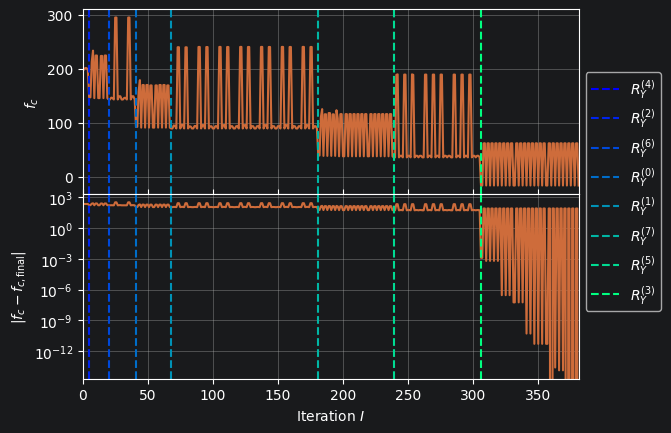

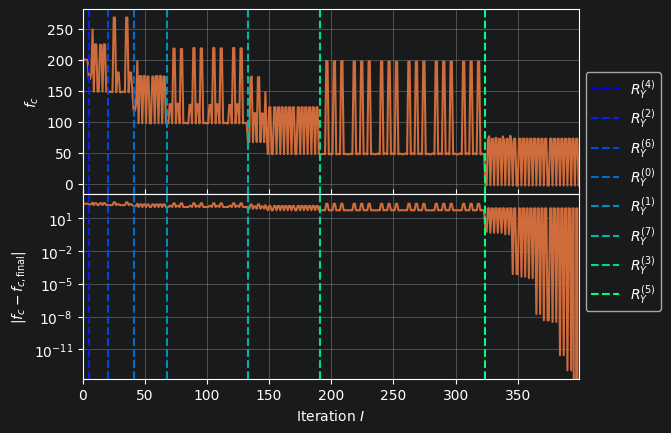

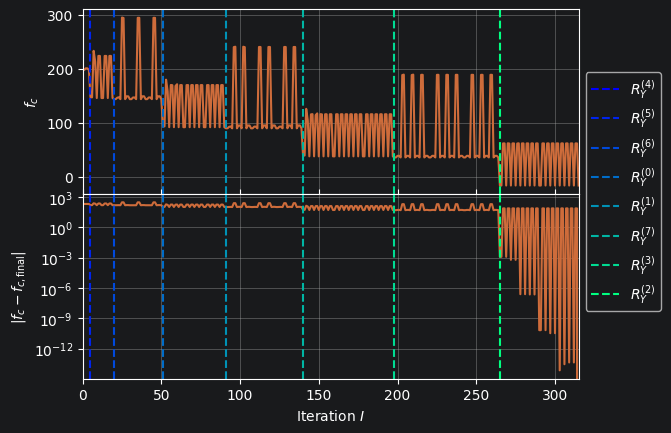

In [22]:
for mass_i in [0, 20, 49]:
    with h5py.File(f"{data_folder}{"2026-07-29"}.hdf5", "r") as f:
        avqe_1_loader = ResultLoader(f["2026-07-24_13-49-50-26631342"])

        params = {HamiltonianParameters.Mass: mass_i}
        param_values = avqe_1_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        avqe_1_energy_evolution = avqe_1_loader.get_energy_evolution(params)
        avqe_1_start_it = np.array(avqe_1_loader.get_start_iterations(params))
        avqe_1_op_labels = avqe_1_loader.get_operator_labels(params)
    fig, (ax1, ax2) = plt.subplots(2, sharex=True)
    ax1.set_axisbelow(True)
    ax1.grid(True)
    ax1.tick_params(axis="x", which="both", direction="in", bottom=True)
    ax2.set_axisbelow(True)
    ax2.grid(True)
    fig.subplots_adjust(hspace=0)

    ax1.plot(avqe_1_energy_evolution, color=color_cycle[1])
    ax1.set(ylabel=r'$f_c$')

    ax2.plot(np.abs(avqe_1_energy_evolution - avqe_1_energy_evolution[-1]), color=color_cycle[1])
    ax2.set_xlim((0, len(avqe_1_energy_evolution) - 1))
    ax2.set_yscale("log")
    ax2.set(xlabel='Iteration $I$', ylabel=r'$|f_c-f_{c,\text{final}}|$')

    ax1_y_lim = ax1.get_ylim()
    ax2_y_lim = ax2.get_ylim()

    cmap = plt.get_cmap("winter")
    norm = plt.Normalize(vmin=0, vmax=len(avqe_1_start_it) - 1)

    for i, (label, it) in enumerate(zip(avqe_1_op_labels, avqe_1_start_it)):
        ax1.vlines(it, ax1_y_lim[0], ax1_y_lim[1], linestyle="--", color=cmap(norm(i)), zorder=2.5, label=label)
        ax2.vlines(it, ax2_y_lim[0], ax2_y_lim[1], linestyle="--", color=cmap(norm(i)), zorder=2.5)

    ax1.set_ylim(ax1_y_lim)
    ax2.set_ylim(ax2_y_lim)
    fig.legend(loc='center left', bbox_to_anchor=(0.9, 0.5))

    fig.savefig(f"{output_filename}test_energy_evolution_{mass_i}.png", bbox_inches='tight', pad_inches=0,
                transparent=True)
    fig.savefig(f"{output_filename}test_energy_evolution_{mass_i}.pdf", bbox_inches='tight', pad_inches=0,
                transparent=True)

In [ ]:
h5_file = f"{data_folder}{"2025-09-35"}.hdf5"
h5_file

In [ ]:
# global_info_dict = {}
# with h5py.File(h5_file, "r") as f:
#     for key, value in f.items():
#         loader = ResultLoader(value)
#         name, info_dict = loader.info_dict({})
#         global_info_dict[name] = info_dict
# with open(f"{output_filename}info.json", "w") as finfo:
#     json.dump(global_info_dict, finfo, sort_keys=True, indent=4, cls=NumpyEncoder)

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    circuit = rebuild_ansatz(f["2025-09-03_11-10-56"])
    circuit = rebuild_ansatz(f["2025-09-03_11-11-36"])
    # circuit = rebuild_ansatz(f["2025-09-03_11-12-33"])
print(circuit.full_ansatz.parameters)
circuit.full_ansatz.draw("mpl", filename=f"{output_filename}vqe_circuit_2_layers.pdf")

In [ ]:
temp = circuit.build_full_ansatz_with_save_points()[0]
print(temp.parameters)
temp.draw("mpl")

In [ ]:
def count_differences(labels: list[str]):
    base_label = "10101010"
    diffs = []
    for label in labels:
        if label:
            temp = 0
            for posit, letter in enumerate(label):
                if letter == base_label[posit]:
                    pass
                else:
                    temp += 1
            diffs.append(temp)
    return diffs


plt.rcParams['figure.constrained_layout.use'] = True
with h5py.File(h5_file, "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    for pos in range(0, 1000, 100):
        print(f"Mass = {ed_mass[pos]:.2f}:")
        gs_fig, gs_labels = ed_loader.plot_ground_state({HamiltonianParameters.Mass: pos})
        gs_diffs = count_differences(gs_labels)
        print("GS", np.sum(gs_diffs), gs_diffs)
        gs_fig.savefig(f"{output_filename}gs_m_{ed_mass[pos]:.2f}.png")
        plt.close(gs_fig)

        es_fig, es_labels = ed_loader.plot_excited_state({HamiltonianParameters.Mass: pos})
        es_diffs = count_differences(es_labels)
        print("ES", np.sum(es_diffs), es_diffs)
        es_fig.savefig(f"{output_filename}es_m_{ed_mass[pos]:.2f}.png")
        plt.close(es_fig)

In [ ]:
with h5py.File(h5_file, "r") as f:
    for pos in range(10, 100, 10):
        ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
        sel = {HamiltonianParameters.Mass: pos * 10}
        print(ed_loader.get_parameter_values_from_indices(sel))
        ref_state = ed_loader.get_ground_state(sel)

        vqe_5_loader = ResultLoader(f["2025-09-06_15-50-13-23147805"])
        sel = {HamiltonianParameters.Mass: pos}
        sel_values = vqe_5_loader.get_parameter_values_from_indices(sel)
        print(sel_values)

        overlaps = vqe_5_loader.save_overlap_evolution(sel, ref_state, output_filename, 1)

In [4]:
h5_file = f"{data_folder}{"2026-07-30"}.hdf5"
datasets = [
    # "2025-10-22_17-19-30-23753926", "2025-10-22_17-24-14-23753943", "2025-10-22_17-30-26-23753983","2025-10-23_13-28-44-23757058",
    # "2025-10-27_10-13-56-23768245", "2025-10-27_10-18-56-23768277", "2025-10-27_10-30-59-23768364", "2025-10-27_10-41-01-23768438", "2025-10-27_10-54-03-23768500", "2025-10-27_11-09-06-23768557"
    # "2025-10-27_12-20-16-23768679"
    # "2025-10-27_16-09-27-23769343", "2025-10-27_16-23-28-23769353", "2025-10-27_16-30-29-23769366", "2025-10-27_16-32-56-23769369", "2025-10-27_16-51-22-23769435", "2025-10-27_16-58-23-23769465", "2025-10-27_17-21-26-23769494",
    # "2025-10-27_18-17-33-23769527",
    # "2025-10-28_12-35-21-23770490", "2025-10-28_12-50-22-23770492", "2025-10-28_12-58-22-23770503", "2025-10-28_13-00-22-23770505"
    # "2025-10-28_14-14-45-23770772", "2025-10-28_14-20-46-23770879", "2025-10-28_14-22-46-23770883", "2025-10-28_14-23-46-23770999"
    # "2025-10-28_15-20-19-23771113", "2025-10-28_15-29-20-23771123", "2025-10-28_15-30-53-23771131",
    # "2025-11-05_12-09-09-23809713",
    # "2025-11-13_14-45-01-23862036",
    # "2025-11-13_14-54-02-23862126", "2025-11-13_15-58-15-23862817", "2025-11-13_16-02-16-23862877", "2025-11-13_16-14-18-23863023", "2025-11-13_16-22-00-23863126", "2025-11-13_16-36-21-23863344",
    # "2025-11-14_15-15-44-23884079",
    # "2025-11-14_14-49-29-23883328", "2025-11-14_17-29-44-23886182",
    # "2025-10-28_12-34-20-23770489",
    # "2025-11-14_17-47-24-23886472", "2025-11-14_18-07-21-23886762",
    # "2025-11-18_11-42-50-23954272",
    # "2025-11-18_12-53-36-23954327",
    # "2025-11-18_13-11-50-23954408",
    # "2025-11-18_13-42-41-23954444",
    # "2025-11-18_13-59-53-23954474", "2025-11-18_14-02-54-23954477", "2025-11-18_16-34-57-23954761",
    # "2025-11-18_16-42-58-23954764",
    # "2025-11-18_17-51-02-23954819", "2025-11-18_17-54-02-23954825", "2025-11-18_17-55-02-23954828", "2025-11-18_17-56-02-23954829", "2025-11-18_17-57-09-23954830", "2025-11-18_17-59-03-23954833", "2025-11-18_18-00-09-23954836", "2025-11-18_18-03-02-23954839", "2025-11-18_18-06-02-23954845"
    # "2025-11-19_11-28-02-23956503",
    # "2025-11-20_15-50-39-23963013",
    # "2025-11-20_16-33-50-23963426", "2025-11-20_16-45-36-23963561", "2025-11-20_16-53-51-23963607", "2025-11-20_17-07-40-23963703", "2025-11-20_17-16-44-23963721", "2025-11-20_17-47-51-23964018", "2025-11-20_17-56-51-23964134",
    # "2025-11-18_13-11-50-23954408", "2025-11-20_16-34-50-23963454", "2025-11-20_16-44-36-23963560", "2025-11-20_16-54-38-23963611", "2025-11-20_17-06-40-23963697", "2025-11-20_17-18-44-23963726", "2025-11-20_17-41-50-23963996", "2025-11-20_17-57-51-23964135",
    # "2025-11-20_18-47-41-23964341", "2025-11-20_18-49-41-23964343", "2025-11-20_18-50-41-23964345",
    # "2025-11-20_18-51-50-23964346", "2025-11-20_18-53-42-23964349", "2025-11-20_18-54-42-23964355",
    # "2025-11-20_18-55-43-23964375"
    # "2026-01-07_14-27-34-24236380",
    # "2026-01-07_14-31-34-24236398",
    # "2026-01-07_14-36-34-24236417",
    # "2026-01-07_14-40-34-24236464",
    # "2026-01-07_15-00-35-24236917",
    # "2026-01-11_00-57-15-24245100", "2026-01-11_01-11-50-24245110", "2026-01-11_01-16-50-24245112"
    # "2026-01-11_12-28-12-24245431", "2026-01-11_12-31-28-24245433", "2026-01-11_12-35-11-24245436", "2026-01-11_12-37-12-24245438",
    # "2026-01-11_12-42-14-24245440", "2026-01-11_13-53-15-24245586", "2026-01-11_14-04-16-24245600",
    # "2026-02-27_00-46-20-24623374",
    # "2026-07-24_13-49-50-26631342",
    # "2026-07-24_14-08-53-26631391",
    # "2026-07-24_14-15-54-26631402",
    # "2026-07-24_14-32-57-26631496",
    # "2026-07-24_15-19-34-26631761",
    # "2026-07-24_16-10-40-26632179",
    # "2026-07-27_17-06-32-26695159", "2026-07-27_17-14-18-26695313", "2026-07-29_18-28-01-26732550", "2026-07-29_18-51-11-26732869",
    "2026-07-30_13-15-42-26737529", "2026-07-30_13-21-03-26737543", "2026-07-30_12-56-02-26737355"
]
combine_data()
global_info_dict = {}
# with h5py.File(h5_file, "r") as f:
#     for key, value in f.items():
#         print(key, value)
#         loader = ResultLoader(value)
#         name, info_dict = loader.info_dict({})
#         global_info_dict[name] = info_dict
# with open(f"{output_filename}info.json", "w") as finfo:
#     json.dump(global_info_dict, finfo, sort_keys=True, indent=4, cls=NumpyEncoder)
h5_file

-----Combining data-----
Skipping combined file 2026-02-08.hdf5
Skipping combined file 2025-10-43.hdf5
Skipping combined file 2025-08-34.hdf5
Skipping combined file 2025-09-35.hdf5
Skipping combined file 2026-07-30.hdf5
Skipping combined file 2025-11-46.hdf5
Skipping combined file 2025-10-42.hdf5
Skipping combined file 2026-07-29.hdf5
Skipping combined file 2026-01-02.hdf5
Skipping combined file 2025-11-45.hdf5
Skipping combined file 2025-08-33.hdf5
Skipping combined file 2025-11-44.hdf5
Skipping combined file 2026-01-01.hdf5
-----Finished combining data-----


'results/data/2026-07-30.hdf5'

/2026-07-30_13-15-42-26737529
/2026-07-30_13-21-03-26737543
/2026-07-30_12-56-02-26737355


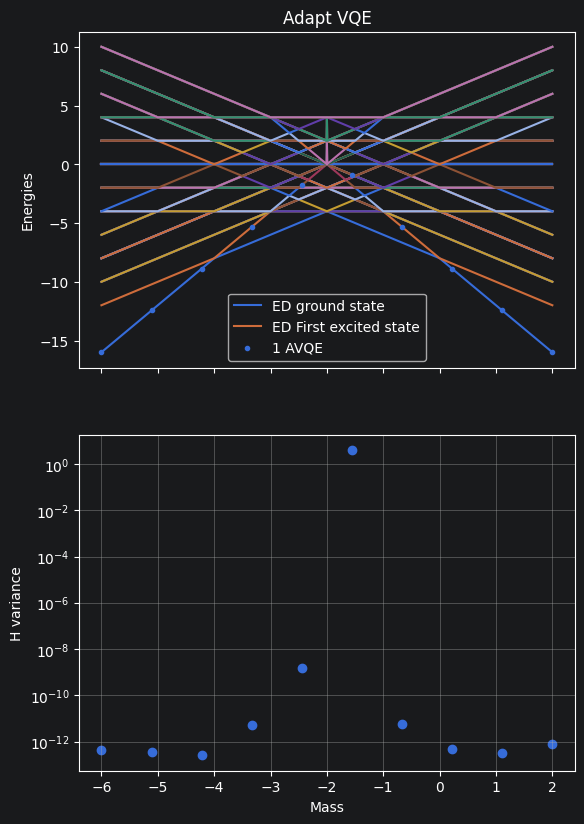

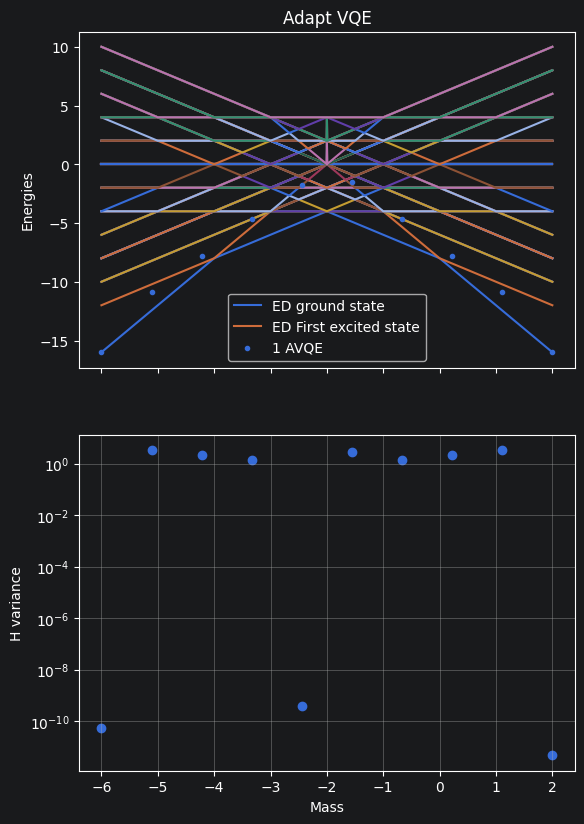

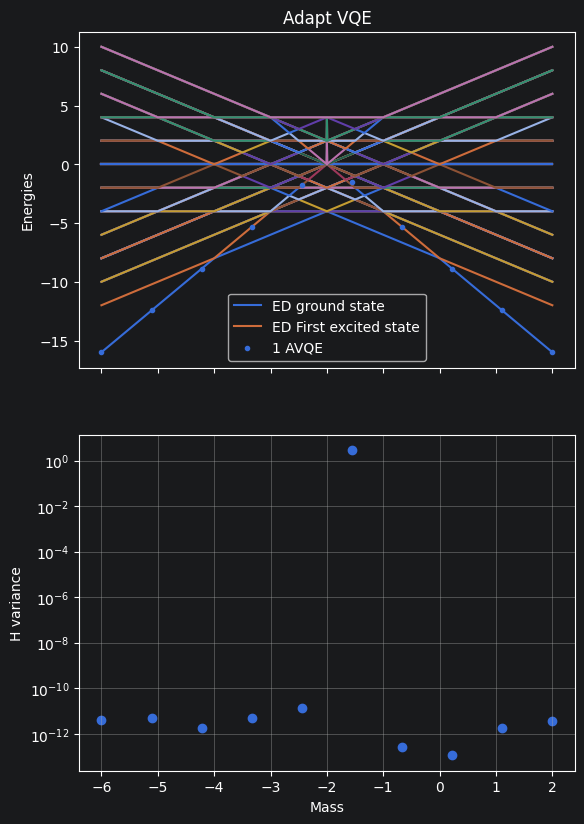

In [5]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
# temp = np.genfromtxt("results/data/4x4_Wilson_r1.csv", delimiter=",")
# ed_mass = temp[:, 0]
# ed_energy = temp[:, 1]
with h5py.File(h5_file, "r") as f:
    for name in datasets:
        print(f[name].name)
        avqe_1_loader = ResultLoader(f[name])
        avqe_1_energy, avqe_1_mass = avqe_1_loader.get_energy_mass({})
        # circuit = avqe_1_loader.get_circuit({HamiltonianParameters.Mass: 2})
        if VQEParameters.HamiltonianVariance in f[name]:
            avqe_1_h_var, avqe_1_mass_v = avqe_1_loader.get_hamiltonian_variance_mass({})
            fig, (ax, var_ax) = plt.subplots(2, sharex=True, figsize=(6.4, 9.6))
            var_ax.scatter(avqe_1_mass_v, avqe_1_h_var)
            ax.set(ylabel='Energies')
            var_ax.set(xlabel='Mass', ylabel='H variance')
            var_ax.grid(True)
            var_ax.set_yscale("log")
        else:
            fig, ax = plt.subplots()
            ax.set(xlabel='Mass', ylabel='Energies')
        # ax.plot(ed_mass, ed_energy, label="ED ground state", zorder=-1)
        ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
        ax.plot(ed_mass, ed_energy[:, 1], label="ED First excited state", zorder=-1)
        ax.plot(ed_mass, ed_energy[:, 2:68], zorder=-1)

        ax.scatter(avqe_1_mass, avqe_1_energy, label="1 AVQE", marker='.')
        ax.set_title("Adapt VQE")
        ax.legend()
        # ax.set_ylim(-20,20)
        fig.savefig(f"{output_filename}test_e_m_{name}.png")
        fig.savefig(f"{output_filename}test_e_m_{name}.pdf")

In [12]:
with h5py.File(h5_file, "r") as f:
    for name in datasets:
        avqe_temp_loader = ResultLoader(f[name])

        # for i in range(0 ,50, 12):
        params = {HamiltonianParameters.Mass: 27}
        param_values = avqe_temp_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])
        circuit = avqe_temp_loader.get_circuit(params, final=True, exit_on_duplicate=False)
        circuit.draw("mpl",
                     filename=f"{output_filename}circuit_m_{param_values[HamiltonianParameters.Mass]:.2f}_{name}.pdf")

['mass=-1.592']
['mass=-1.592']


In [ ]:
with h5py.File(h5_file, "r") as f:
    for name in datasets:
        avqe_1_loader = ResultLoader(f[name])
        params = {HamiltonianParameters.Mass: 2}
        param_values = avqe_1_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        fig = avqe_1_loader.plot_derivatives(params)
        fig.savefig(f"{output_filename}grad_m_{param_values[HamiltonianParameters.Mass]:.2f}_{name}.png")
        fig.savefig(f"{output_filename}grad_m_{param_values[HamiltonianParameters.Mass]:.2f}_{name}.pdf")

In [ ]:
with h5py.File(h5_file, "r") as f:
    for name in datasets:
        avqe_1_loader = ResultLoader(f[name])
        params = {HamiltonianParameters.Mass: 2}
        param_values = avqe_1_loader.get_parameter_values_from_indices(params)
        print([f"{x}={y:.3f}" for x, y in param_values.items()])

        fig = avqe_1_loader.plot_derivatives(params, True)

        fig.savefig(f"{output_filename}sec_grad_m_{param_values[HamiltonianParameters.Mass]:.2f}_{name}.png")
        fig.savefig(f"{output_filename}sec_grad_m_{param_values[HamiltonianParameters.Mass]:.2f}_{name}.pdf")

In [ ]:
with h5py.File(h5_file, "r") as f:
    avqe_loader = ResultLoader(f[datasets[0]])

    params = {HamiltonianParameters.Mass: 1}
    param_values = avqe_loader.get_parameter_values_from_indices(params)
    print([f"{x}={y:.3f}" for x, y in param_values.items()])

    temp = np.array(f[datasets[-1]]["MetaData"]["target_precision"])
    # print(np.array(f[datasets[-1]]["Data"]["stds"]["Hamiltonian"]))
    energy = avqe_loader.get_energy_evolution(params)
    it = np.array(avqe_loader.get_start_iterations(params))
    print(avqe_loader.get_operator_labels(params))
    print(it[1:] - it[:-1])

In [ ]:
fig, ax = plt.subplots()
ax.plot(energy)
ax.vlines(it, 0, 10, linestyle="--", color="red", alpha=0.3, zorder=-1)
# ax.set_xlim(51140, 51160)
# ax.set_ylim(195,205)

In [ ]:
fig, ax = plt.subplots()
ax.plot(temp.T)

In [ ]:
from solver.circuits import HardwareAdaptAnsatz11

test = HardwareAdaptAnsatz11(8)
test.set_ansatz([0])
test.full_ansatz.draw("mpl")

In [ ]:
fig, ax = plt.subplots()

with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})

ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED First excited state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 2:68], zorder=-1)

with h5py.File(f"{data_folder}{"2025-11-44-42"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-11-06_16-28-01-42"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})

ax.scatter(ed_mass, ed_energy[:, 0], label="ED compressed ground state", zorder=-1, marker='.')
ax.scatter(ed_mass, ed_energy[:, 1], label="ED compressed First excited state", zorder=-1, marker='.')
ax.plot(ed_mass, ed_energy[:, 2:64], zorder=-1, linestyle="", marker='.')

ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Ed compression")
ax.legend()

In [ ]:
with h5py.File(f"{data_folder}{"2025-11-45"}.hdf5", "r") as f:
    avqe_loader = ResultLoader(f["2025-11-13_14-45-01-23862036"])
    params = {HamiltonianParameters.Mass: 20}
    param_values = avqe_loader.get_parameter_values_from_indices(params)
    print([f"{x}={y:.3f}" for x, y in param_values.items()])
    print(avqe_loader.get_operator_labels(params))

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
name = "2025-11-20_18-55-43-23964375-rerun-23972382"
h5_file = f"{data_folder}{"2025-11-46-23972382"}.hdf5"
avqe_1_mass = []
avqe_1_energy = []
with h5py.File(h5_file, "r") as f:
    group = f[name]
    for key in group.keys():
        print(f"{key}")
        if "rerun" in key:
            continue
        avqe_loader = ResultLoader(group[key])
        energy, dep, _ = avqe_loader.get_observables(VQEParameters.Hamiltonian, {}, [])
        avqe_1_energy.append(energy)
        avqe_1_mass.append(group[key].attrs[HamiltonianParameters.Mass])
fig, ax = plt.subplots()
ax.plot(ed_mass, ed_energy[:, 0], label="ED ground state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 1], label="ED First excited state", zorder=-1)
ax.plot(ed_mass, ed_energy[:, 2:68], zorder=-1)

ax.scatter(avqe_1_mass, avqe_1_energy, label="1 AVQE", marker='.')
ax.set(xlabel='Mass', ylabel='Energies')
ax.set_title("Adapt VQE")
ax.legend()
fig.savefig(f"{output_filename}e_m_{name}.png")
fig.savefig(f"{output_filename}e_m_{name}.pdf")

In [ ]:
h5_file = f"{data_folder}{"2025-11-46"}.hdf5"
datasets = ["2025-11-18_11-42-50-23954272"]
combine_data()
h5_file

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
    ed_c, _ = ed_loader.get_charge_conjugation_mass({})
    ed_c_v, _ = ed_loader.get_charge_conjugation_variance_mass({})

with h5py.File(h5_file, "r") as f:
    for name in datasets:
        print(f[name].name)

        fig, ax = plt.subplots()
        ax.set(xlabel='Mass', ylabel='Energies')
        cmap = plt.get_cmap('bwr')
        norm = plt.Normalize(vmin=-1, vmax=1)

        avqe_1_loader = ResultLoader(f[name])
        avqe_1_energy, avqe_1_mass = avqe_1_loader.get_energy_mass({})
        if VQEParameters.ChargeConjugation in f[name]:
            avqe_1_c, avqe_1_mass_c = avqe_1_loader.get_charge_conjugation_mass({})
            ax.scatter(avqe_1_mass, avqe_1_energy, c=avqe_1_c, norm=norm, cmap=cmap, label="AVQE", marker='.')
        else:
            ax.scatter(avqe_1_mass, avqe_1_energy, label="AVQE", marker='.')

        for i in range(68):
            points = np.array([ed_mass, ed_energy[:, i]]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap=cmap, norm=norm)
            lc.set_array(ed_c[:, i])
            lc.set_zorder(-(i + 1))
            if i == 0:
                lc.set_label("ED")
            line = ax.add_collection(lc)

        ax.set_xlim(ed_mass.min() - 0.5, ed_mass.max() + 0.5)
        ax.set_ylim(min(ed_energy[:, :68].min(), avqe_1_energy.min()) * 1.05,
                    max(ed_energy[:, :68].max(), avqe_1_energy.max()) * 1.05)
        cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
        cbar.set_label(r'$\left\langle C \right\rangle$')

        ax.legend()
        fig.show()
        fig.savefig(f"{output_filename}e_c_m_{name}.png")
        fig.savefig(f"{output_filename}e_c_m_{name}.pdf")

In [ ]:
with h5py.File(f"{data_folder}{"2025-09-35"}.hdf5", "r") as f:
    ed_loader = ResultLoader(f["2025-09-03_22-35-17"])
    ed_energy, ed_mass = ed_loader.get_energy_mass({})
    ed_c, _ = ed_loader.get_charge_conjugation_mass({})
    ed_c_v, _ = ed_loader.get_charge_conjugation_variance_mass({})

print(ed_energy.shape, ed_mass.shape)

datasets = [
    ("2025-11-45", "2025-11-13_14-45-01-23862036", "Greedy"),
    ("2026-01-01", "2026-01-07_14-31-34-24236398", r"$\alpha_0=+1$"),
    ("2026-01-02", "2026-01-11_00-57-15-24245100", r"$\alpha_0=-1$"),
    ("2026-01-02", "2026-01-11_01-16-50-24245112", r"$\alpha_0=-1$"),
]
fig, ax = plt.subplots()
ax.set(xlabel='Mass', ylabel='Energies')
cmap = plt.get_cmap('bwr')
norm = plt.Normalize(vmin=-1, vmax=1)

for i in range(68):
    points = np.array([ed_mass, ed_energy[:, i]]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(ed_c[:, i])
    lc.set_zorder(-(i + 1))
    if i == 0:
        lc.set_label("ED")
    line = ax.add_collection(lc)

avqe_energies = []
avqe_masses = None
for local_h5_file, name, label in datasets:
    with h5py.File(f"{data_folder}{local_h5_file}.hdf5", "r") as f:
        avqe_1_loader = ResultLoader(f[name])
        avqe_1_energy, avqe_1_mass = avqe_1_loader.get_energy_mass({})
        avqe_masses = avqe_1_mass
        avqe_energies.append(avqe_1_energy)
        print(f[name].name)
        # ax.scatter(avqe_1_mass, avqe_1_energy, label=label, marker='.')
        # if VQEParameters.ChargeConjugation in f[name]:
        #     avqe_1_c, avqe_1_mass_c = avqe_1_loader.get_charge_conjugation_mass({})
        #     ax.scatter(avqe_1_mass, avqe_1_energy, c=avqe_1_c, norm=norm, cmap=cmap, label="AVQE", marker='.')
        # else:
        #     ax.scatter(avqe_1_mass, avqe_1_energy, label="AVQE", marker='.')
        #     # raise ValueError("Measure first")

avqe_energies = np.sort(np.array(avqe_energies), axis=0)[:2]
ax.scatter(avqe_masses, avqe_energies[0], label="GS", marker='.')
ax.scatter(avqe_masses, avqe_energies[1], label="1. ES", marker='.')

ax.set_xlim(ed_mass.min() - 0.5, ed_mass.max() + 0.5)
ax.set_ylim(min(ed_energy[:, :68].min(), avqe_1_energy.min()) * 1.05,
            max(ed_energy[:, :68].max(), avqe_1_energy.max()) * 1.05)
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
cbar.set_label(r'$\left\langle C \right\rangle$')

ax.legend()
fig.show()
fig.savefig(f"{output_filename}e_c_m_combined.pdf")
fig.savefig(f"{output_filename}e_c_m_combined.png")